ValueError: When stacked is True, each column must be either all positive or all negative. Column 'Land Use, Land-Use Change and Forestry' contains both positive and negative values

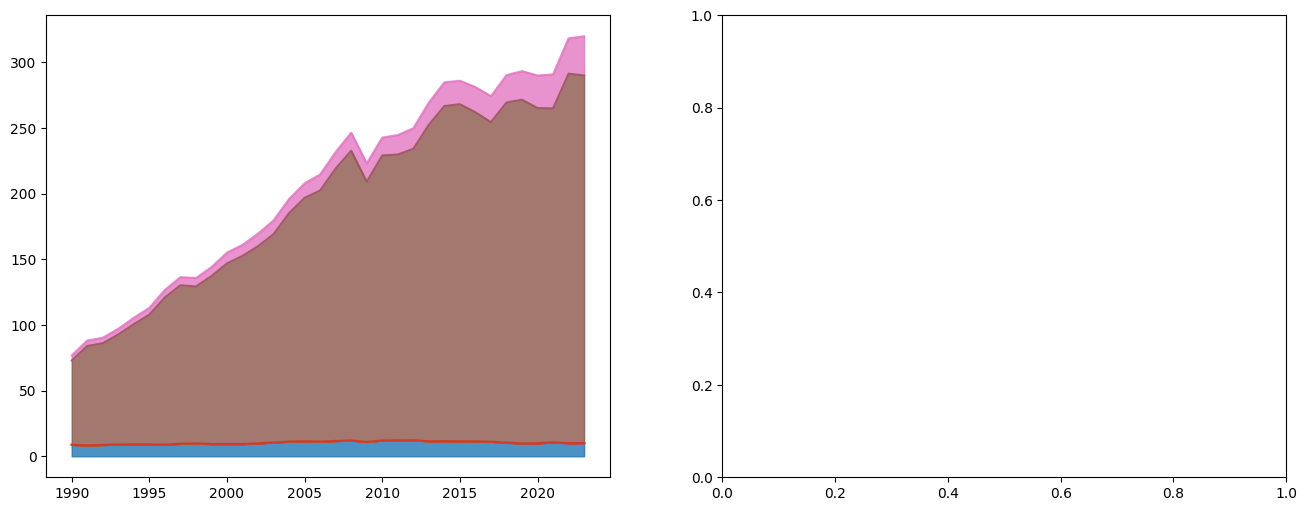

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Ensure outputs directory exists
Path('../outputs').mkdir(parents=True, exist_ok=True)

df = pd.read_csv('../data/processed/cleaned_wdi.csv')
df_cw = pd.read_csv('../data/processed/ghg-emissions.csv')

# Reshape wide GHG CSV into long format for sector analysis
year_cols = [c for c in df_cw.columns if c.isdigit()]
df_cw_sectors = df_cw[df_cw['unit'].notna()].melt(
    id_vars=['Sector'], value_vars=year_cols,
    var_name='year', value_name='ghg_mtco2e'
)
df_cw_sectors['year'] = df_cw_sectors['year'].astype(int)
df_cw_sectors.rename(columns={'Sector': 'sector'}, inplace=True)

# ── PHYSICAL + TRANSITION INDICATOR JUSTIFICATION TABLE ───────────────────────
indicator_table = {
    'Indicator': [
        'CHIRPS 3-day max precipitation',
        'WDI Total GHG (EN.ATM.GHGT.KT.CE)',
        'WDI Urban population % (SP.URB.TOTL.IN.ZS)',
        'WDI Land below 5m (EN.CLC.MDAT.ZS)',
        'WDI GDP per capita (NY.GDP.PCAP.CD)',
        'NOAA ONI (El Niño/La Niña index)',
        'NGFS Carbon price (Current Policies)',
        'NGFS Carbon price (Net Zero 2050)',
        'Climate Watch: Energy sector GHG',
        'Climate Watch: Industry sector GHG'
    ],
    'Risk Type': [
        'Physical', 'Physical/Transition', 'Physical',
        'Physical', 'Physical', 'Physical',
        'Transition', 'Transition', 'Transition', 'Transition'
    ],
    'Cat Layer': [
        'Hazard', 'Hazard', 'Vulnerability',
        'Vulnerability', 'Loss', 'Hazard (Dependence)',
        'Loss (Regulatory)', 'Loss (Regulatory)', 
        'Transition Exposure', 'Transition Exposure'
    ],
    'Actuarial Justification': [
        'Sub-national daily rainfall: direct input to GEV model. 3-day max drives flood event peak flow',
        'Upstream atmospheric forcing. IPCC AR6: +7% extreme precip per °C. ARIMA target for R2',
        'Insured asset concentration. Same flood footprint × more urban density = higher loss per event',
        'Coastal surge amplification. Non-linear loss at inundation threshold for property portfolios',
        'Insurance penetration driver. Higher GDP → more insured value per km² of flood footprint',
        'Inter-annual loss dependence. La Niña → MYS flood spike. El Niño → PHL drought, but storm surge intensification post-event',
        'Regulatory compliance cost for carbon-intensive cedant portfolios under current policy trajectory',
        'BNM-grade carbon price under Paris-aligned transition. Direct input to CCPT compliance cost estimate',
        'Energy sector = largest GHG contributor → highest transition cost exposure for Malaysian cedants',
        'Heavy industry stranded asset risk → treaty loss amplification through property write-downs'
    ]
}
pd.DataFrame(indicator_table).to_csv('../outputs/r1_indicator_table.csv', index=False)

# ── CLIMATE WATCH SECTOR DECOMPOSITION CHART ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Stacked area chart — sector GHG over time
pivot = df_cw_sectors.pivot_table(
    index='year', columns='sector', values='ghg_mtco2e', aggfunc='sum'
).fillna(0)

pivot.plot.area(ax=axes[0], colormap='tab10', alpha=0.8)
axes[0].set_title('Malaysia GHG Emissions by Sector (Climate Watch)\n'
                   'Energy + Industry = Primary Transition Risk Exposure for Cedants',
                   fontweight='bold')
axes[0].set_ylabel('GHG Emissions (Mt CO₂e)')
axes[0].set_xlabel('Year')
axes[0].legend(loc='upper left', fontsize=9)

# Right: Share of total by sector (most recent year)
latest_year = df_cw_sectors['year'].max()
sector_share = df_cw_sectors[df_cw_sectors['year']==latest_year].groupby('sector')['ghg_mtco2e'].sum()
colors = ['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd']
axes[1].pie(sector_share.values, labels=sector_share.index, 
             colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Sector GHG Share ({int(latest_year)})\n'
                   'Identifies which cedant industries face highest CCPT regulatory cost',
                   fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/r1_climate_watch_sectors.png', dpi=150, bbox_inches='tight')